In [1]:
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df=pd.read_csv(r"C:\Users\VASAB\Downloads\online_retail.csv\online_retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### Data Understanding

In [5]:
df.shape

(541909, 8)

In [6]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Cleaning

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df['Description']=df['Description'].fillna(df['Description'].mode()[0])

In [11]:
df['CustomerID']=df['CustomerID'].fillna(df['CustomerID'].mode()[0])

In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
df=df.drop_duplicates()

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Remove invaild transcations

df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]

In [17]:
# convert data column

df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [18]:
# Create revenue column

df['Revenue']=df['Quantity']*df['UnitPrice']

In [19]:
# Extract time features

df['Month']=df['InvoiceDate'].dt.month
df['Year']=df['InvoiceDate'].dt.year

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010


### Exploratory Data Analysis

In [21]:
import matplotlib.pyplot as plt

In [26]:
df['Quantity'].describe()

count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

In [27]:
df['Quantity'].quantile([0.25,0.50,0.75,0.90,0.95,0.99])

0.25      1.0
0.50      4.0
0.75     11.0
0.90     24.0
0.95     30.0
0.99    100.0
Name: Quantity, dtype: float64

In [35]:
df[df['Quantity']<100]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,2011
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,2011
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011


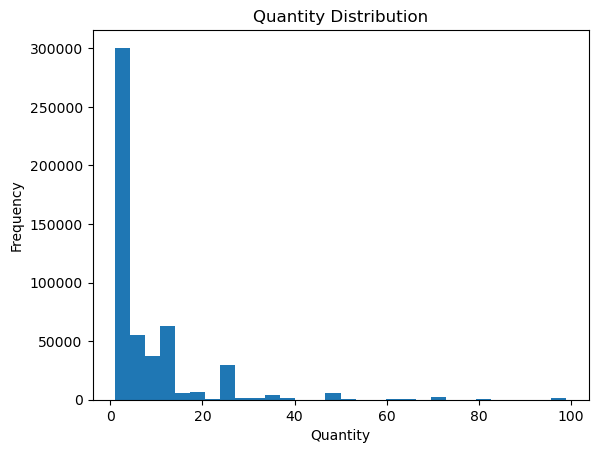

In [36]:
plt.hist(df[df['Quantity']<100]['Quantity'],bins=30)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Quantity Distribution')
plt.show()

##### Insights:
The quantity distribution is highly right=skewed, with most transactions involving small quantities and a few transactions having significantly higher quantities.

In [60]:
df['UnitPrice'].describe()

count    524878.000000
mean          3.922573
std          36.093028
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

In [61]:
df[df['UnitPrice']<=0].shape

(0, 11)

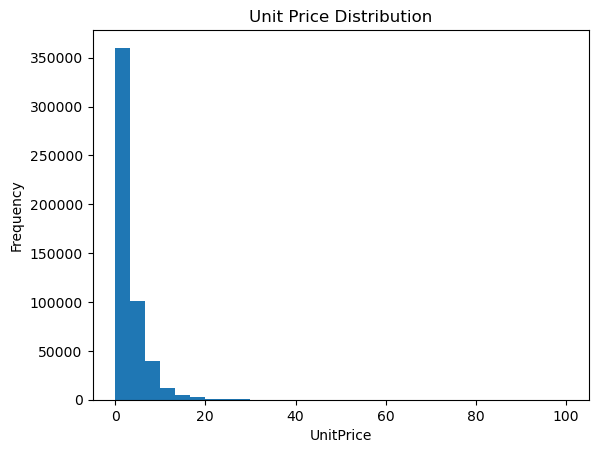

In [62]:
plt.hist(df[df['UnitPrice']<100]['UnitPrice'],bins=30)
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')
plt.title('Unit Price Distribution')
plt.show()

##### Insights:
Unit Price  distribution is highly right-skewed,with most products having relatively low prices and a small number of trfansactions showing unusually high unit prices.

In [63]:
country_sales.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [64]:
country_sales=df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

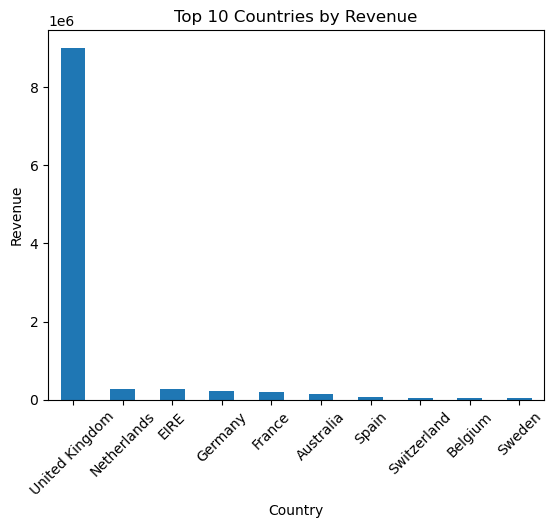

In [65]:
country_sales.head(10).plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.title('Top 10 Countries by Revenue')
plt.xticks(rotation=45)
plt.show()

##### Insights:
Country-level analysis showed that the united kingdom was the dominant revenue-generating market,followed by the Netherland and EIRE, highlighting the concentration of sales across key European markets.

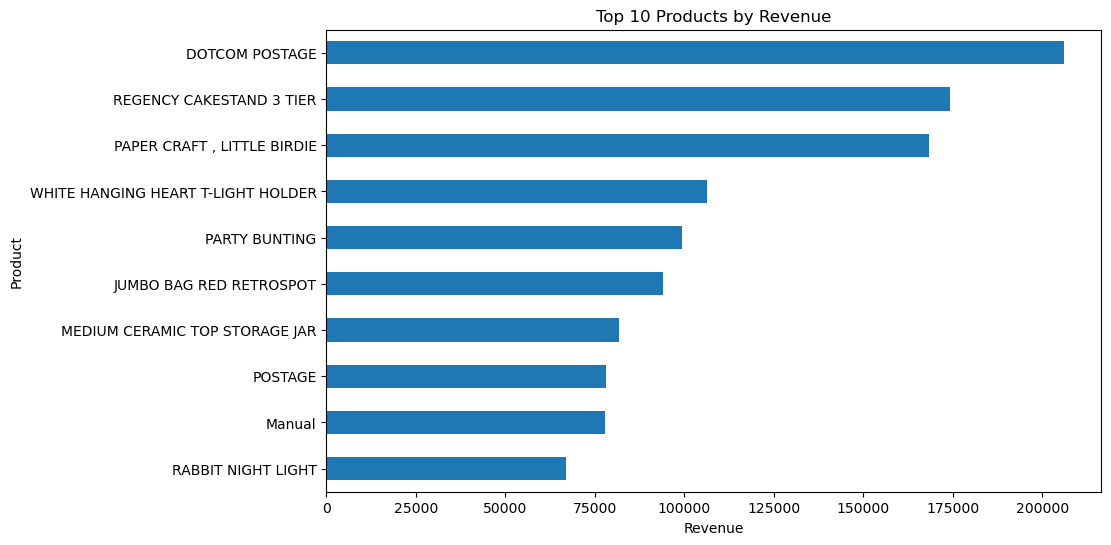

In [66]:
product_sales=df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

product_sales.sort_values().plot(kind='barh',figsize=(10,6))
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')
plt.show()

##### Insights:
Product-level analysis showed that a small group of products contributed significantly to overall revenue,highlighting key products that drive sales performance.

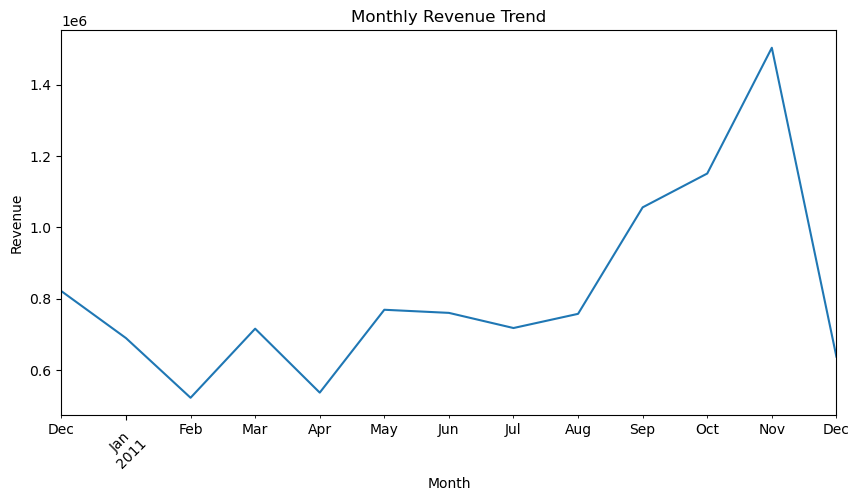

In [67]:
monthly_sales=df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
monthly_sales.plot(figsize=(10,5))

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()

##### Insights:
Monthly revenue fluctuated throughout the year, with a significant increase from August and a peak in November, indicating a strong seasonal sales pattern.

In [78]:
df[['Quantity','UnitPrice','Revenue']].corr()

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


In [79]:
import seaborn as sns

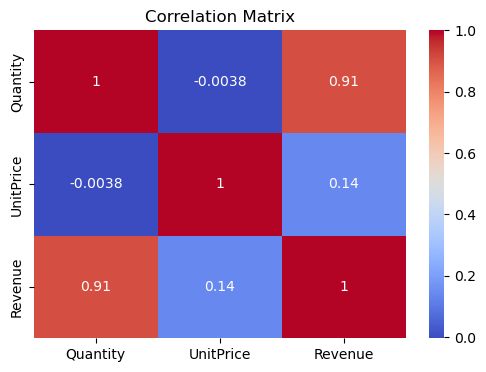

In [80]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Quantity','UnitPrice','Revenue']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

##### Insights:
Correlation analysis revealed a strong positive relationship between quantity sold and revenue(r=0.91), indicating that sales volume is a major contributor to revenue.

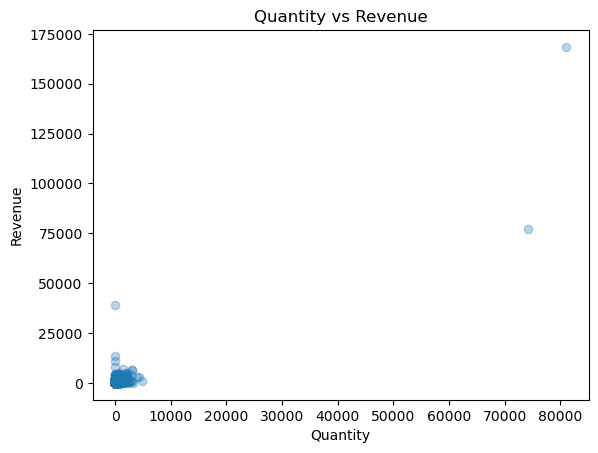

In [81]:
plt.scatter(df['Quantity'],df['Revenue'],alpha=0.3)
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.title('Quantity vs Revenue')
plt.show()

##### Insights:
The analysis shows a strong positive relationship between quantity sold annd revenue, indicating that sales volume is a major contributor to revenue.

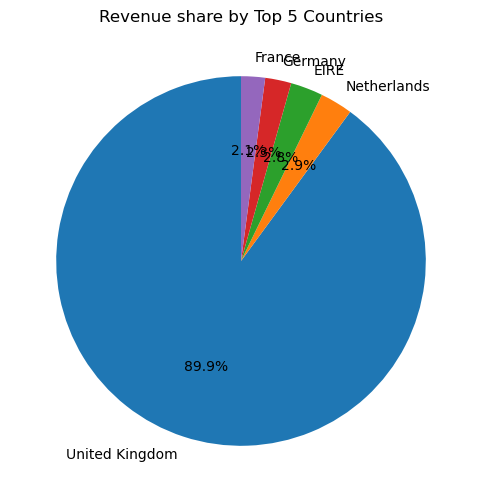

In [82]:
country_revenue=df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,6))
plt.pie(country_revenue,labels=country_revenue.index,autopct='%1.1f%%',startangle=90)
plt.title('Revenue share by Top 5 Countries')
plt.show()

##### Insights:
The revenue-share analysis shows that the United Kingdom contributes the largest share of total revenue, indicating that it is the primary market driving overall sales performance.